# Early Stopping + Loss History on SJAFFE

Trains five neural-net LDL models on the **SJAFFE** dataset with a uniform
recipe:

- max **2500** epochs (an upper bound — early stopping cuts it short),
- `LDLEarlyStopping(monitor='kl_divergence', patience=50)`, restoring
  best weights when triggered,
- `LossHistory` captures per-epoch training loss and validation KL,
- 80 / 20 train/test split (the test split doubles as the validation set
  for early-stopping signal).

For each model we plot training loss + validation KL on twin axes, then a
combined comparison and a final test-score table.


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from pyldl.utils import load_dataset, LDLEarlyStopping, LossHistory
from pyldl.algorithms import AA_BP, Duo_LDL, EDL_LDL, BEDL_LDL, SNEFY_LDL, SA_BFGS


E0000 00:00:1777259568.239299 2442877 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777259568.243356 2442877 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777259568.255963 2442877 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777259568.255978 2442877 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777259568.255980 2442877 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777259568.255981 2442877 computation_placer.cc:177] computation placer already registered. Please check linka

## Load SJAFFE

In [2]:
X, D = load_dataset('Natural_Scene', dir='dataset')
X_train, X_test, D_train, D_test = train_test_split(X, D, test_size=0.2, random_state=0)
X_val, X_test, D_val, D_test = train_test_split(X_test, D_test, test_size=0.5, random_state=0)
print(f'X_train={X_train.shape}  D_train={D_train.shape}')
print(f'X_val  ={X_val.shape}    D_val  ={D_val.shape}')
print(f'X_test ={X_test.shape}   D_test ={D_test.shape}')


X_train=(1600, 294)  D_train=(1600, 9)
X_val  =(200, 294)    D_val  =(200, 9)
X_test =(200, 294)   D_test =(200, 9)


In [3]:
X_train.min(), X_train.max()

(np.float64(0.0), np.float64(0.999969482))

## Training helper

`train_with_history` runs one model with the standard early-stopping +
loss-history callback pair and returns both the trained model and the
captured history.

`AA_BP` gets `AdamW(1e-2)` because its inherited default is
`SGD(1e-3)`, which converges far too slowly to see meaningful behaviour
inside 2500 epochs. The other four models inherit `Adam(1e-3)` from
`BaseAdam` and we leave that alone for an apples-to-apples comparison.


In [10]:
def train_with_history(name, model, **fit_kwargs):
    history = LossHistory()
    callbacks = [
        LDLEarlyStopping(monitor='kl_divergence', patience=100),
        history,
    ]
    print(f'--- training {name} ---')
    model.fit(
        X_train, D_train,
        epochs=2500, batch_size=64,
        X_val=X_val, D_val=D_val,
        callbacks=callbacks,
        **fit_kwargs,
    )
    n_epochs = len(history.history.get('loss', []))
    print(f'  finished after {n_epochs} epochs')
    return model, history


## Train each model

In [ ]:
results = {}

learning_rate = 1e-3
weight_decay = 1e-4
dropout_rate = 0.2

results['AA_BP'] = train_with_history(
    'AA_BP', AA_BP(),
    optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
    dropout_rate=dropout_rate,
)
results['Duo_LDL']   = train_with_history('Duo_LDL',   Duo_LDL(n_hidden=64),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
        dropout_rate=dropout_rate)
results['EDL_LDL']   = train_with_history('EDL_LDL',   EDL_LDL(n_hidden=64),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
        dropout_rate=dropout_rate)
results['BEDL_LDL']  = train_with_history('BEDL_LDL',  BEDL_LDL(n_hidden=64),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
        dropout_rate=dropout_rate)
results['EDL_LDL_bayes']   = train_with_history('EDL_LDL_bayes',   EDL_LDL(n_hidden=64),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
        loss_type='bayes_mse',
        dropout_rate=dropout_rate)
results['BEDL_LDL_bayes']  = train_with_history('BEDL_LDL_bayes',  BEDL_LDL(n_hidden=64),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
        loss_type='bayes_mse',
        dropout_rate=dropout_rate)
results['SNEFY_LDL'] = train_with_history('SNEFY_LDL', SNEFY_LDL(),
        optimizer=keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
        dropout_rate=dropout_rate)


--- training AA_BP ---
  finished after 487 epochs
--- training Duo_LDL ---


TypeError: _BaseDeep.fit() got an unexpected keyword argument 'dropout_rate'

## Per-model loss curves

Training loss (blue, left axis) and validation KL divergence (red, right
axis) on twin axes. Early-stopping fires when the val-KL curve fails to
improve for 50 epochs; the model's final weights are restored to the
best-val-KL epoch.


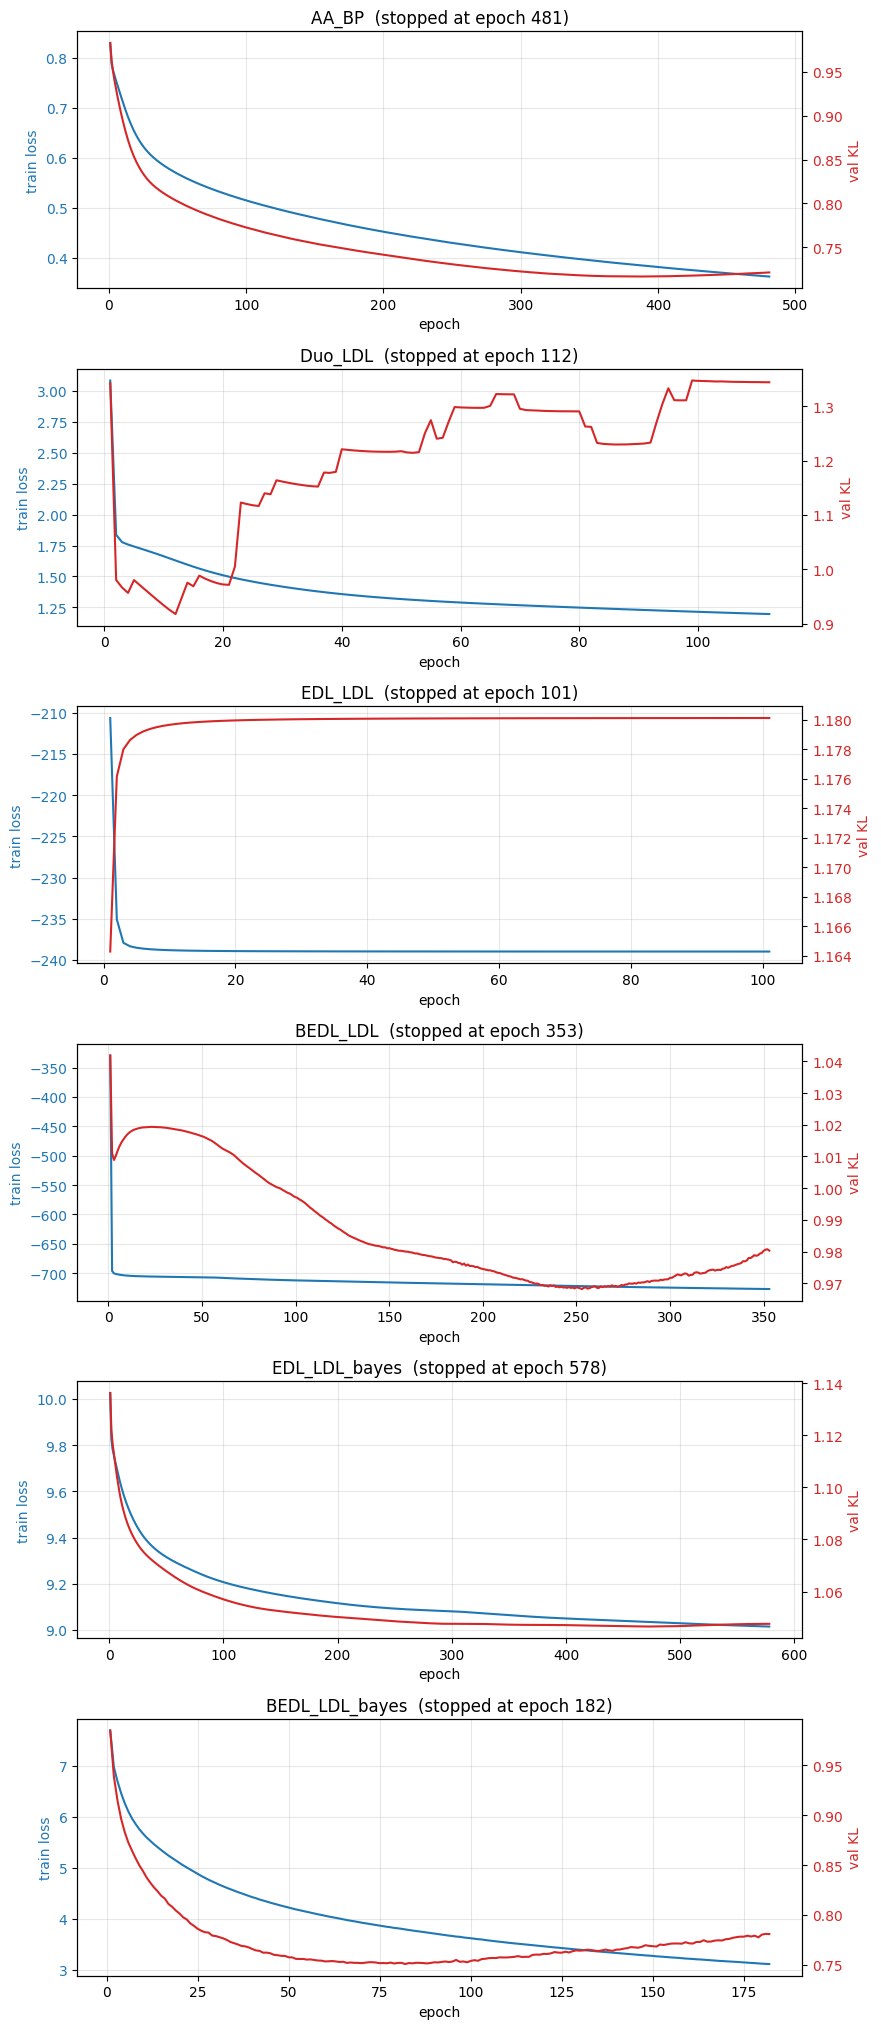

In [6]:
fig, axes = plt.subplots(len(results), 1, figsize=(9, 3.4 * len(results)), squeeze=False)

for ax_row, (name, (_, h)) in zip(axes, results.items()):
    ax = ax_row[0]
    ep = range(1, len(h.history['loss']) + 1)
    ax.plot(ep, h.history['loss'], color='C0', label='train loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('train loss', color='C0')
    ax.tick_params(axis='y', labelcolor='C0')

    ax2 = ax.twinx()
    ax2.plot(ep, h.history['kl_divergence'], color='C3', label='val KL')
    ax2.set_ylabel('val KL', color='C3')
    ax2.tick_params(axis='y', labelcolor='C3')

    ax.set_title(f'{name}  (stopped at epoch {len(ep)})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Validation KL comparison across models

All five val-KL curves on a single axis. Useful for seeing which models
converge faster vs. which reach a lower final KL.


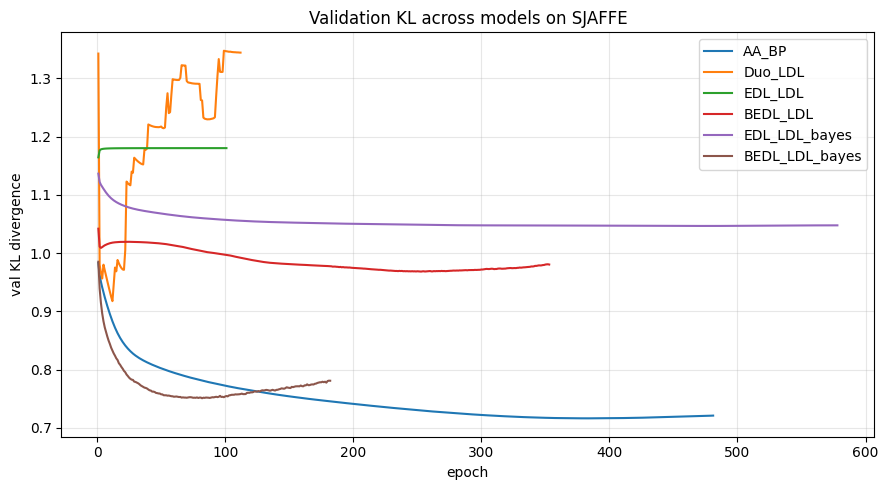

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, (_, h) in results.items():
    kl = h.history['kl_divergence']
    ax.plot(range(1, len(kl) + 1), kl, label=name)

ax.set_xlabel('epoch'); ax.set_ylabel('val KL divergence')
ax.set_title('Validation KL across models on SJAFFE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Final test-set scores

Computed on `X_test` / `D_test` after early-stopping has restored each
model to its best-val-KL weights.


In [8]:
METRICS = ['chebyshev', 'clark', 'canberra', 'kl_divergence', 'cosine', 'intersection']

rows = []
for name, (model, h) in results.items():
    s = model.score(X_test, D_test, metrics=METRICS, return_dict=True)
    rows.append({
        'model': name,
        'epochs_run': len(h.history.get('loss', [])),
        **{k: float(v) for k, v in s.items()},
    })

scores_df = pd.DataFrame(rows).set_index('model')
scores_df


,epochs_run,chebyshev,clark,canberra,kl_divergence,cosine,intersection
model,,,,,,,
AA_BP,481,0.274286,2.425292,6.611366,0.662325,0.794995,0.616628
Duo_LDL,112,0.362808,2.480853,6.842223,0.953000,0.706912,0.477772
EDL_LDL,101,0.407238,2.504397,7.026528,1.206265,0.582872,0.373283
BEDL_LDL,353,0.383697,2.487179,6.899229,0.966028,0.679674,0.452188
EDL_LDL_bayes,578,0.382475,2.498624,7.009515,1.067400,0.641878,0.394351
BEDL_LDL_bayes,182,0.284727,2.448193,6.682428,0.678232,0.792785,0.596896


In [9]:
sa_bfgs_mod = SA_BFGS()
sa_bfgs_mod.fit(X_train, D_train)
scores = sa_bfgs_mod.score(X_test, D_test, return_dict=True)
print(f'--- {sa_bfgs_mod.__class__.__name__} ---')
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

--- SA_BFGS ---
chebyshev: 0.3385
clark: 2.4370
canberra: 6.7344
kl_divergence: 0.8255
cosine: 0.7184
intersection: 0.5411
